In [1]:
import pandas as pd
import os

# LOAD AND INSPECT DATASET (AUTO-FIND)

target_file = 'PGCB_date_power_demand.xlsx'
file_path = None

for root, dirs, files in os.walk('/kaggle/input'):
    if target_file in files:
        file_path = os.path.join(root, target_file)
        break

if file_path is None:
    print(f"Error: Could not find '{target_file}'.")
else:
    print(f"Success! File found at: {file_path}")
    print("Loading dataset, please wait...")
    
    # Read the Excel dataset
    df = pd.read_excel(file_path)

    # Print dataset dimensions and column structure
    print("\n" + "="*40)
    print(f" Dataset successfully loaded!")
    print(f" Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print("="*40 + "\n")

    # Display the first 5 rows
    print("--- FIRST 5 ROWS ---")
    display(df.head())

    # Display data types and missing value counts for each column
    print("\n--- COLUMN INFO ---")
    print(df.info())

Success! File found at: /kaggle/input/datasets/aabuyousufraj1552/pgcb-date-power-demand/PGCB_date_power_demand.xlsx
Loading dataset, please wait...

 Dataset successfully loaded!
 Shape: 92650 rows × 15 columns

--- FIRST 5 ROWS ---


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN



--- COLUMN INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              92650 non-null  datetime64[ns]
 1   generation_mw         92650 non-null  float64       
 2   demand_mw             92650 non-null  int64         
 3   load_shedding         92650 non-null  int64         
 4   gas                   92650 non-null  int64         
 5   liquid_fuel           92650 non-null  int64         
 6   coal                  92650 non-null  int64         
 7   hydro                 92650 non-null  int64         
 8   solar                 70517 non-null  float64       
 9   wind                  18676 non-null  float64       
 10  india_bheramara_hvdc  92650 non-null  int64         
 11  india_tripura         92650 non-null  int64         
 12  india_adani           7338 non-null   float64       


Starting EDA & Preprocessing...

----------------------------------------
1. INITIAL CHECKS & ALIGNMENT
----------------------------------------
Initial data shape: (92650, 14)
Initial missing values in target: 0

----------------------------------------
2. RESAMPLING & MISSING VALUES
----------------------------------------
Data shape after resampling to strict 1-hour intervals: (89101, 1)
Missing hours exposed by resampling: 1051
Missing hours after time-based interpolation: 0 (Handled successfully!)

----------------------------------------
3. OUTLIER TREATMENT
----------------------------------------
Applied IQR clipping. Boundaries set at: [989.50 MW, 16321.50 MW]

----------------------------------------
4. FEATURE ENGINEERING
----------------------------------------
Adding calendar features (hour, day of week, month)...
Applying cyclical encoding to 'hour' to link 23:00 and 00:00...
Generating lag features (t-1, t-2, t-24, t-168) and 24h rolling stats...
Dropped 168 rows contain

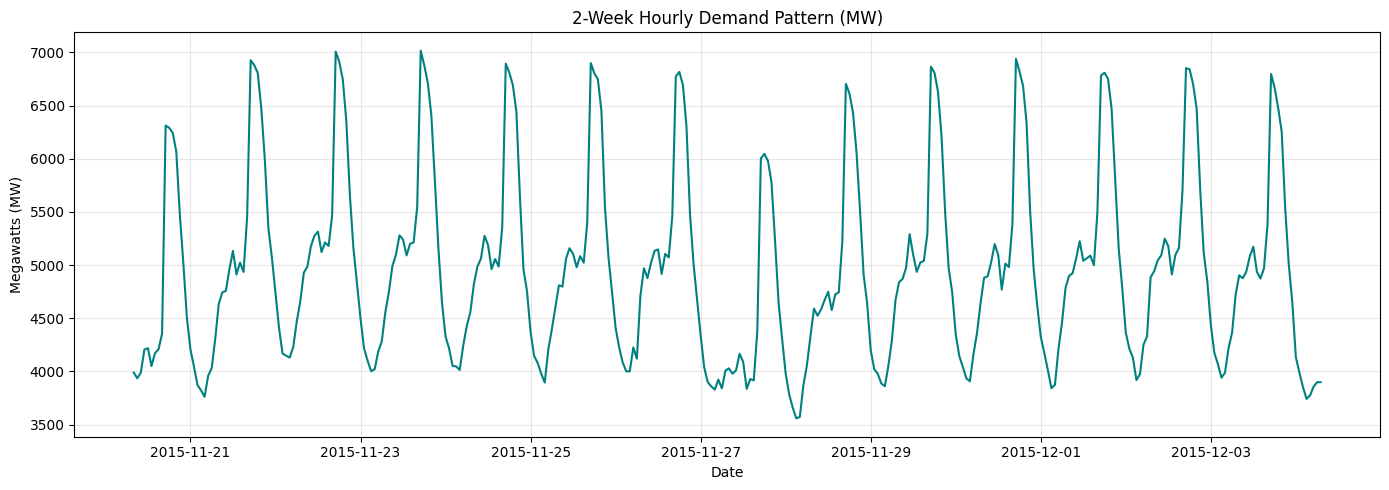

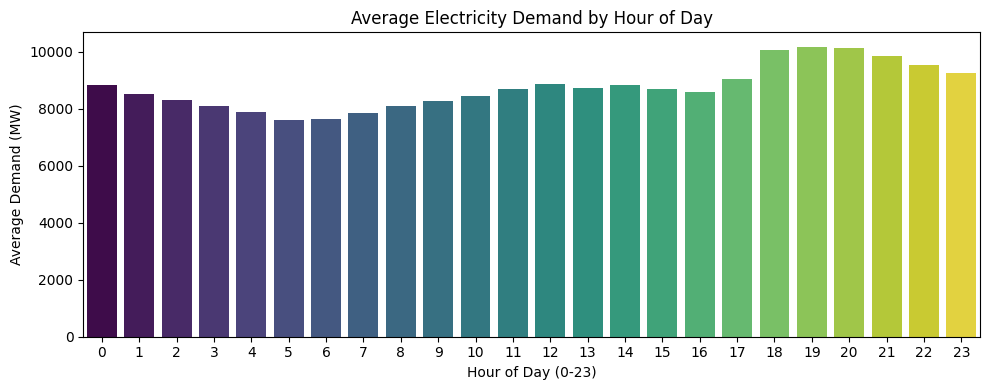

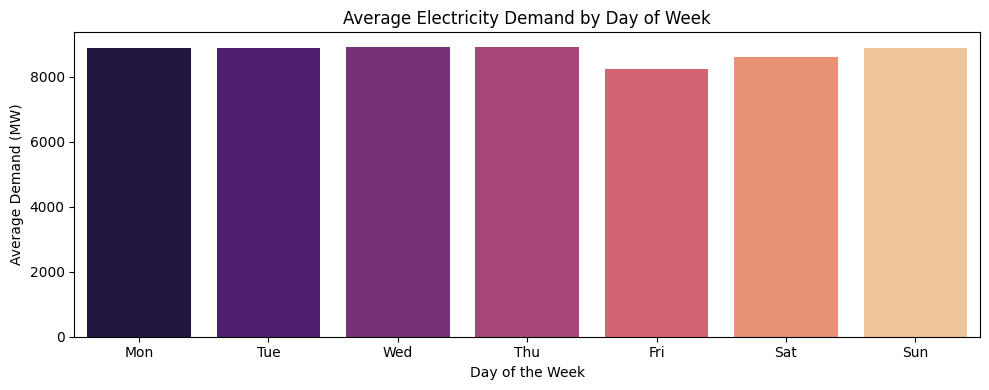

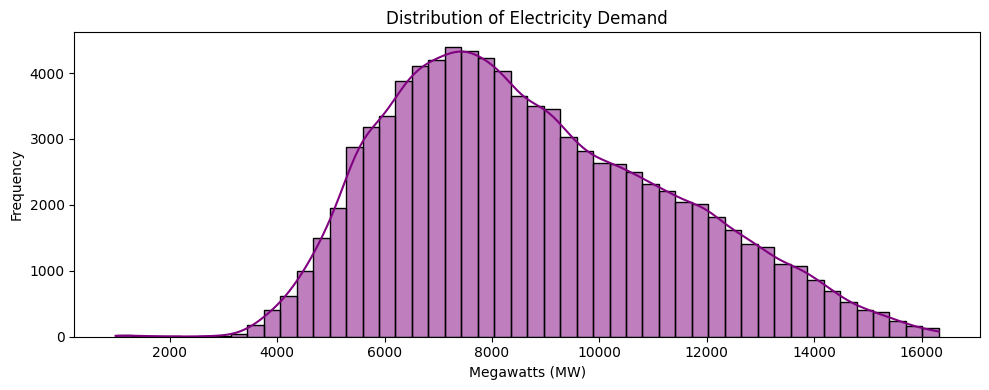

✅ All EDA plots saved to: /kaggle/working/


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# STEP 2: EDA & PREPROCESSING
# ==========================================
# Set up Kaggle output directory for saving plots
SAVE_DIR = '/kaggle/working/'
os.makedirs(SAVE_DIR, exist_ok=True)

print("Starting EDA & Preprocessing...\n")
print("-" * 40)
print("1. INITIAL CHECKS & ALIGNMENT")
print("-" * 40)

# Set index and fix the backward sorting
df = df.set_index('datetime').sort_index()
print(f"Initial data shape: {df.shape}")
print(f"Initial missing values in target: {df['demand_mw'].isna().sum()}")

print("\n" + "-" * 40)
print("2. RESAMPLING & MISSING VALUES")
print("-" * 40)

# Isolate the target and fix the uneven time intervals (Resampling)
df_clean = df[['demand_mw']].resample('h').mean()
print(f"Data shape after resampling to strict 1-hour intervals: {df_clean.shape}")

missing_after_resample = df_clean['demand_mw'].isna().sum()
print(f"Missing hours exposed by resampling: {missing_after_resample}")

# Fill any missing hours that the resampling exposed
df_clean['demand_mw'] = df_clean['demand_mw'].interpolate(method='time')
print(f"Missing hours after time-based interpolation: {df_clean['demand_mw'].isna().sum()} (Handled successfully!)")

print("\n" + "-" * 40)
print("3. OUTLIER TREATMENT")
print("-" * 40)

# Light Outlier Treatment (Clipping)
Q1 = df_clean['demand_mw'].quantile(0.25)
Q3 = df_clean['demand_mw'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean['demand_mw'] = df_clean['demand_mw'].clip(lower=lower_bound, upper=upper_bound)
print(f"Applied IQR clipping. Boundaries set at: [{lower_bound:.2f} MW, {upper_bound:.2f} MW]")

print("\n" + "-" * 40)
print("4. FEATURE ENGINEERING")
print("-" * 40)

# Feature Engineering (Calendar Features)
print("Adding calendar features (hour, day of week, month)...")
df_clean['hour'] = df_clean.index.hour
df_clean['dow'] = df_clean.index.dayofweek
df_clean['month'] = df_clean.index.month

# Cyclical encoding for hours
print("Applying cyclical encoding to 'hour' to link 23:00 and 00:00...")
df_clean['hour_sin'] = np.sin(2 * np.pi * df_clean['hour'] / 24)
df_clean['hour_cos'] = np.cos(2 * np.pi * df_clean['hour'] / 24)

# Feature Engineering (Lags and Rolling Windows)
print("Generating lag features (t-1, t-2, t-24, t-168) and 24h rolling stats...")
for lag in [1, 2, 24, 168]:
    df_clean[f'lag_{lag}'] = df_clean['demand_mw'].shift(lag)

df_clean['roll_mean_24'] = df_clean['demand_mw'].shift(1).rolling(window=24).mean()
df_clean['roll_std_24'] = df_clean['demand_mw'].shift(1).rolling(window=24).std()

# Drop NaNs introduced by the shifts
rows_before_drop = len(df_clean)
df_clean = df_clean.dropna()
print(f"Dropped {rows_before_drop - len(df_clean)} rows containing NaNs introduced by the 168-hour lag shift.")

print(f"\n✅ Preprocessing complete! Final modeling shape: {df_clean.shape}")

# Assigning to the final variable name we will use for modeling
final_df = df_clean.copy()

# ==========================================
# QUICK EDA VISUALIZATIONS (Saved to Output)
# ==========================================
print("\nGenerating and saving EDA plots...")

# Plot 1: 2-Week Hourly Pattern
plt.figure(figsize=(14, 5))
plt.plot(df_clean['demand_mw'].iloc[5000:5336], color='teal') 
plt.title("2-Week Hourly Demand Pattern (MW)")
plt.ylabel("Megawatts (MW)")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'eda_1_2week_pattern.png'), dpi=300)
plt.show()

# Plot 2: Average Demand by Hour of Day
plt.figure(figsize=(10, 4))
hourly_avg = df_clean.groupby('hour')['demand_mw'].mean()
sns.barplot(x=hourly_avg.index, y=hourly_avg.values, hue=hourly_avg.index, palette='viridis', legend=False)
plt.title("Average Electricity Demand by Hour of Day")
plt.ylabel("Average Demand (MW)")
plt.xlabel("Hour of Day (0-23)")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'eda_2_hourly_avg.png'), dpi=300)
plt.show()

# Plot 3: Average Demand by Day of Week (Great for report!)
plt.figure(figsize=(10, 4))
dow_avg = df_clean.groupby('dow')['demand_mw'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.barplot(x=days, y=dow_avg.values, hue=days, palette='magma', legend=False)
plt.title("Average Electricity Demand by Day of Week")
plt.ylabel("Average Demand (MW)")
plt.xlabel("Day of the Week")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'eda_3_dow_avg.png'), dpi=300)
plt.show()

# Plot 4: Distribution of Demand
plt.figure(figsize=(10, 4))
sns.histplot(df_clean['demand_mw'], bins=50, kde=True, color='purple')
plt.title("Distribution of Electricity Demand")
plt.xlabel("Megawatts (MW)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'eda_4_distribution.png'), dpi=300)
plt.show()

print(f"✅ All EDA plots saved to: {SAVE_DIR}")

Starting Steps 3, 4, and 5 (with Strict Logging, CV, & Loss Curves)...
Data Split -> Train: 87853 rows, Val: 360 rows, Test: 720 rows

[1/3] Tuning Random Forest (TimeSeries CV)...
Best RF Params: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 15}

[2/3] Training LSTM with Validation Tracking...
Starting Epochs:
Epoch  1/50 | Train Loss: 0.007772 | Val Loss: 0.009449
Epoch  2/50 | Train Loss: 0.002775 | Val Loss: 0.001928
Epoch  3/50 | Train Loss: 0.001210 | Val Loss: 0.000927
Epoch  4/50 | Train Loss: 0.000951 | Val Loss: 0.000884
Epoch  5/50 | Train Loss: 0.000877 | Val Loss: 0.000876
Epoch  6/50 | Train Loss: 0.000825 | Val Loss: 0.001074
Epoch  7/50 | Train Loss: 0.000763 | Val Loss: 0.000949
Epoch  8/50 | Train Loss: 0.000709 | Val Loss: 0.000647
Epoch  9/50 | Train Loss: 0.000673 | Val Loss: 0.000565
Epoch 10/50 | Train Loss: 0.000642 | Val Loss: 0.000555
Epoch 11/50 | Train Loss: 0.000617 | Val Loss: 0.000489
Epoch 12/50 | Train Loss: 0.000602 | Val Loss: 0.000486
Ep

06:59:24 - cmdstanpy - INFO - Chain [1] start processing
07:00:58 - cmdstanpy - INFO - Chain [1] done processing



 FINAL EVALUATION METRICS
Random Forest   | MAE: 199.57  | RMSE: 275.08  | MAPE: 1.60%
LSTM            | MAE: 347.39  | RMSE: 469.78  | MAPE: 2.80%
Prophet         | MAE: 1136.13 | RMSE: 1474.43 | MAPE: 9.72%


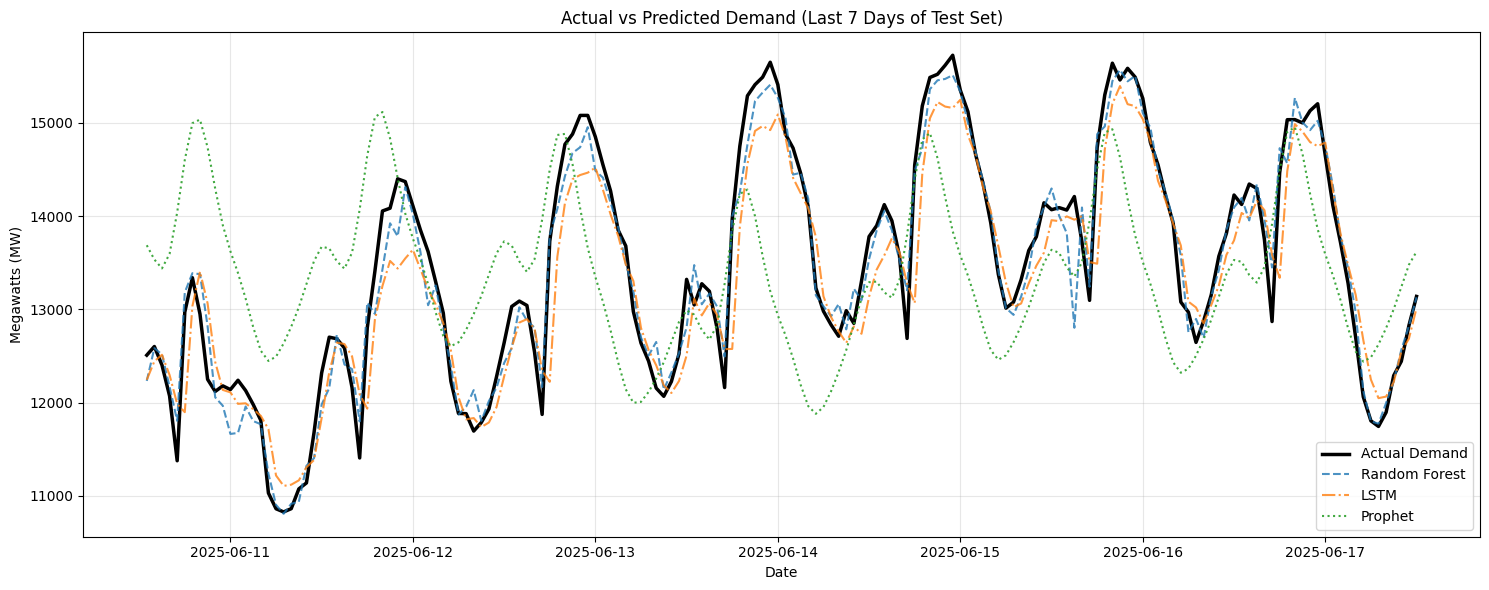


✅ All artifacts rigorously tracked and saved to '/kaggle/working/' in 7.46 minutes.


In [3]:
!pip install prophet --quiet

import os
import joblib
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import logging
import copy

print("Starting Steps 3, 4, and 5 (with Strict Logging, CV, & Loss Curves)...")
start_time = time.time()

# ==========================================
# DIRECTORY SETUP FOR EXPORTING
# ==========================================
SAVE_DIR = '/kaggle/working/'
os.makedirs(SAVE_DIR, exist_ok=True)

# ==========================================
# STEP 3 & 4: TARGET & TIME-SERIES SPLITTING
# ==========================================
TARGET = 'demand_mw'

test_size = 24 * 30  # Last 30 days for testing
val_size = 24 * 15   # 15 days before test for LSTM validation

train_end = -(test_size + val_size)
val_end = -test_size

train = final_df.iloc[:train_end].copy()
val = final_df.iloc[train_end:val_end].copy()
test = final_df.iloc[val_end:].copy()

features = [col for col in final_df.columns if col != TARGET]
X_train, y_train = train[features], train[TARGET]
X_val, y_val = val[features], val[TARGET]
X_test, y_test = test[features], test[TARGET]

print(f"Data Split -> Train: {X_train.shape[0]} rows, Val: {X_val.shape[0]} rows, Test: {X_test.shape[0]} rows")

# ==========================================
# STEP 5: BUILD, TUNE, TRAIN, & LOG MODELS
# ==========================================

# --- 1. Tuned Random Forest with TimeSeriesSplit ---
print("\n[1/3] Tuning Random Forest (TimeSeries CV)...")
tscv = TimeSeriesSplit(n_splits=3)
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_random = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=rf_param_grid, 
    n_iter=4, 
    cv=tscv, 
    scoring='neg_mean_absolute_error', 
    random_state=42,
    n_jobs=-1
)

# Combine train and val for CV
X_train_rf = pd.concat([X_train, X_val])
y_train_rf = pd.concat([y_train, y_val])

rf_random.fit(X_train_rf, y_train_rf)
best_rf = rf_random.best_estimator_
print(f"Best RF Params: {rf_random.best_params_}")

# Save RF model and CV results
joblib.dump(best_rf, os.path.join(SAVE_DIR, 'rf_model.pkl'))
cv_results = pd.DataFrame(rf_random.cv_results_)
cv_results.to_csv(os.path.join(SAVE_DIR, 'rf_cv_results.csv'), index=False)

rf_preds = best_rf.predict(X_test)

# --- 2. PyTorch LSTM with Early Stopping & Loss Tracking ---
print("\n[2/3] Training LSTM with Validation Tracking...")
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

X_val_scaled = scaler_X.transform(X_val)
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1))

X_test_scaled = scaler_X.transform(X_test)

joblib.dump(scaler_X, os.path.join(SAVE_DIR, 'scaler_X.pkl'))
joblib.dump(scaler_y, os.path.join(SAVE_DIR, 'scaler_y.pkl'))

def to_tensor(X, y=None):
    if y is not None:
        return torch.FloatTensor(X).unsqueeze(1), torch.FloatTensor(y)
    return torch.FloatTensor(X).unsqueeze(1)

X_train_t, y_train_t = to_tensor(X_train_scaled, y_train_scaled)
X_val_t, y_val_t = to_tensor(X_val_scaled, y_val_scaled)
X_test_t = to_tensor(X_test_scaled)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=False)

class TunedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lstm_model = TunedLSTM(input_size=X_train.shape[1]).to(device)
criterion = nn.HuberLoss() 
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

EPOCHS = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

# Track history
train_losses = []
val_losses = []

print("Starting Epochs:")
for epoch in range(EPOCHS):
    lstm_model.train()
    train_loss_sum = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = lstm_model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item() * batch_x.size(0)
    
    avg_train_loss = train_loss_sum / len(train_loader.dataset)
    
    # Validation phase
    lstm_model.eval()
    with torch.no_grad():
        val_preds = lstm_model(X_val_t.to(device))
        val_loss = criterion(val_preds, y_val_t.to(device)).item()
    
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1:>2}/{EPOCHS} | Train Loss: {avg_train_loss:.6f} | Val Loss: {val_loss:.6f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = copy.deepcopy(lstm_model.state_dict())
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print(f"--> Early stopping triggered at epoch {epoch+1}!")
        break

# Save LSTM History & Model
pd.DataFrame({'Epoch': range(1, len(train_losses)+1), 'Train_Loss': train_losses, 'Val_Loss': val_losses}).to_csv(os.path.join(SAVE_DIR, 'lstm_training_history.csv'), index=False)
lstm_model.load_state_dict(best_model_state)
torch.save(lstm_model.state_dict(), os.path.join(SAVE_DIR, 'lstm_model.pt'))

# Plot and save Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='orange')
plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'lstm_loss_curve.png'), dpi=300)
plt.close() # Close to prevent showing it alongside the final plot

# Predict
lstm_model.eval()
with torch.no_grad():
    lstm_preds_scaled = lstm_model(X_test_t.to(device)).cpu().numpy()
lstm_preds = scaler_y.inverse_transform(lstm_preds_scaled).flatten()

# --- 3. Tuned Facebook Prophet ---
print("\n[3/3] Training Facebook Prophet...")
logging.getLogger('cmdstanpy').setLevel(logging.ERROR) 
prophet_train = pd.concat([train, val]).reset_index()[['datetime', TARGET]].rename(columns={'datetime': 'ds', TARGET: 'y'})

m = Prophet(daily_seasonality=True, yearly_seasonality=True, weekly_seasonality=True, changepoint_prior_scale=0.05)
m.fit(prophet_train)
future = m.make_future_dataframe(periods=len(test), freq='h')
forecast = m.predict(future)
prophet_preds = forecast['yhat'].iloc[-len(test):].values

forecast.to_csv(os.path.join(SAVE_DIR, 'prophet_forecast.csv'), index=False)

# ==========================================
# FINAL EVALUATION & DASHBOARD EXPORT
# ==========================================
print("\n" + "="*40)
print(" FINAL EVALUATION METRICS")
print("="*40)

results = []
def evaluate_and_store(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"{model_name:<15} | MAE: {mae:<7.2f} | RMSE: {rmse:<7.2f} | MAPE: {mape:.2f}%")
    results.append({'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape})

evaluate_and_store(y_test, rf_preds, "Random Forest")
evaluate_and_store(y_test, lstm_preds, "LSTM")
evaluate_and_store(y_test, prophet_preds, "Prophet")

pd.DataFrame(results).to_csv(os.path.join(SAVE_DIR, 'evaluation_metrics.csv'), index=False)

# Dashboard Data Export
dashboard_data = test[[TARGET]].copy()
dashboard_data['RF_Pred'] = rf_preds
dashboard_data['LSTM_Pred'] = lstm_preds
dashboard_data['Prophet_Pred'] = prophet_preds
dashboard_data.to_csv(os.path.join(SAVE_DIR, 'dashboard_data.csv'))

# Plotting Actual vs Predicted
plt.figure(figsize=(15, 6))
plot_days = 24 * 7 
plt.plot(y_test.index[-plot_days:], y_test.values[-plot_days:], label='Actual Demand', color='black', linewidth=2.5)
plt.plot(y_test.index[-plot_days:], rf_preds[-plot_days:], label='Random Forest', linestyle='--', alpha=0.8)
plt.plot(y_test.index[-plot_days:], lstm_preds[-plot_days:], label='LSTM', linestyle='-.', alpha=0.8)
plt.plot(y_test.index[-plot_days:], prophet_preds[-plot_days:], label='Prophet', linestyle=':', alpha=0.9)

plt.title("Actual vs Predicted Demand (Last 7 Days of Test Set)")
plt.xlabel("Date")
plt.ylabel("Megawatts (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'actual_vs_predicted.png'), dpi=300)
plt.show()

print(f"\n✅ All artifacts rigorously tracked and saved to '{SAVE_DIR}' in {(time.time() - start_time)/60:.2f} minutes.")

Starting LightGBM Quantile Regression (Novel Loss Approach)...
Training Quantile 0.1...
Training Quantile 0.5...
Training Quantile 0.9...

 LIGHTGBM (QUANTILE 0.5) EVALUATION
LightGBM Median | MAE: 196.55  | RMSE: 267.43  | MAPE: 1.59%


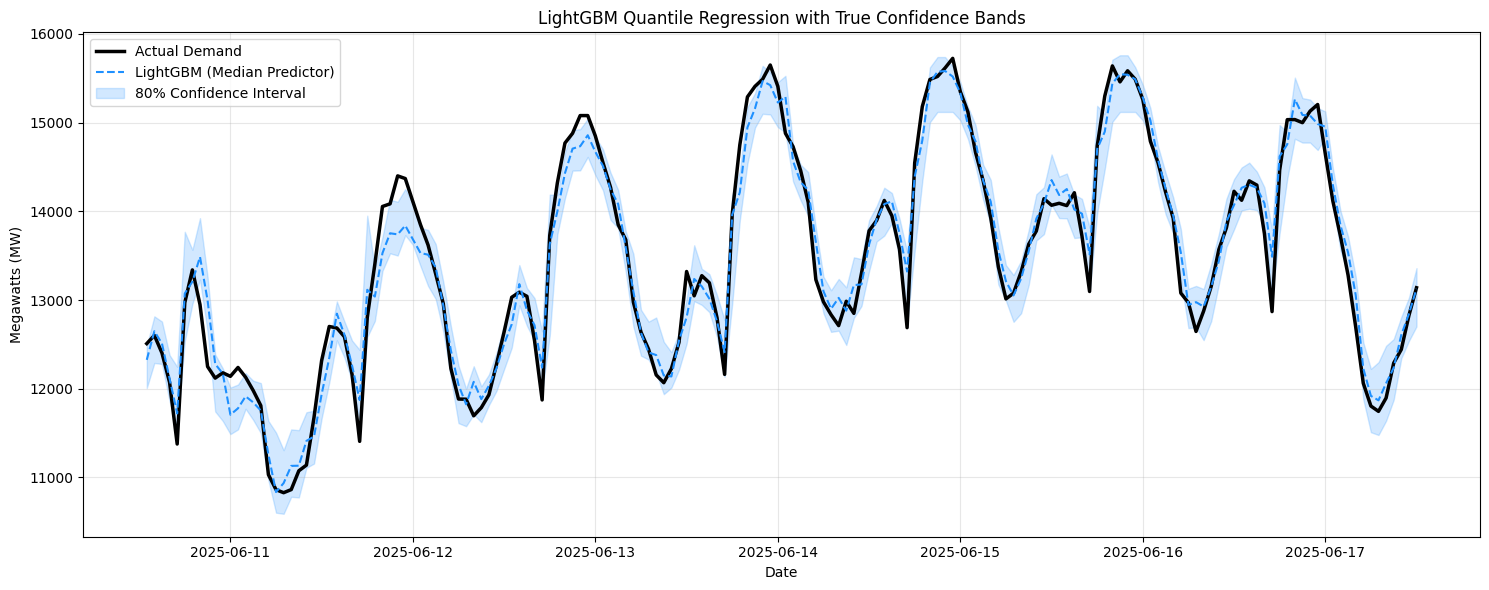


✅ Novel model trained and artifacts saved in 4.96 seconds.


In [4]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import time
import os
import joblib

print("Starting LightGBM Quantile Regression (Novel Loss Approach)...")
start_time = time.time()

# ==========================================
# 1. TRAIN QUANTILE MODELS (PINBALL LOSS)
# ==========================================
# We predict the 10th (lower bound), 50th (median/main prediction), and 90th (upper bound) percentiles
quantiles = [0.1, 0.5, 0.9]
models = {}
preds = {}

# Combine train and val sets for maximum data exposure
X_train_lgb = pd.concat([X_train, X_val])
y_train_lgb = pd.concat([y_train, y_val])

for q in quantiles:
    print(f"Training Quantile {q}...")
    model = lgb.LGBMRegressor(
        objective='quantile',
        alpha=q,              # This is the Pinball Loss parameter
        n_estimators=300,
        learning_rate=0.05,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
        verbose=-1            # Silences LightGBM warnings
    )
    model.fit(X_train_lgb, y_train_lgb)
    models[q] = model
    preds[q] = model.predict(X_test)

# The 50th percentile (Median) is our main prediction
lgb_main_preds = preds[0.5]
lgb_lower_bound = preds[0.1]
lgb_upper_bound = preds[0.9]

# ==========================================
# 2. EVALUATION
# ==========================================
print("\n" + "="*40)
print(" LIGHTGBM (QUANTILE 0.5) EVALUATION")
print("="*40)

mae = mean_absolute_error(y_test, lgb_main_preds)
rmse = np.sqrt(mean_squared_error(y_test, lgb_main_preds))
mape = mean_absolute_percentage_error(y_test, lgb_main_preds) * 100

print(f"LightGBM Median | MAE: {mae:<7.2f} | RMSE: {rmse:<7.2f} | MAPE: {mape:.2f}%")

# ==========================================
# 3. EXPORT DASHBOARD ARTIFACTS
# ==========================================
SAVE_DIR = '/kaggle/working/'
joblib.dump(models[0.5], os.path.join(SAVE_DIR, 'lgbm_model.pkl'))

# Save the predictions AND the mathematical bounds for the dashboard
lgbm_results = pd.DataFrame({
    'Date': y_test.index,
    'Actual': y_test.values,
    'LGBM_Pred': lgb_main_preds,
    'LGBM_Lower_90': lgb_lower_bound,
    'LGBM_Upper_90': lgb_upper_bound
})
lgbm_results.to_csv(os.path.join(SAVE_DIR, 'lgbm_confidence_bands.csv'), index=False)

# ==========================================
# 4. PLOT WITH TRUE CONFIDENCE BANDS
# ==========================================
plt.figure(figsize=(15, 6))
plot_days = 24 * 7 

# Isolate the last 7 days
dates = y_test.index[-plot_days:]
actuals = y_test.values[-plot_days:]
main_line = lgb_main_preds[-plot_days:]
lower_line = lgb_lower_bound[-plot_days:]
upper_line = lgb_upper_bound[-plot_days:]

plt.plot(dates, actuals, label='Actual Demand', color='black', linewidth=2.5)
plt.plot(dates, main_line, label='LightGBM (Median Predictor)', color='dodgerblue', linestyle='--')

# Draw the mathematically proven confidence band
plt.fill_between(dates, lower_line, upper_line, color='dodgerblue', alpha=0.2, label='80% Confidence Interval')

plt.title("LightGBM Quantile Regression with True Confidence Bands")
plt.xlabel("Date")
plt.ylabel("Megawatts (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'lgbm_quantile_plot.png'), dpi=300)
plt.show()

print(f"\n✅ Novel model trained and artifacts saved in {(time.time() - start_time):.2f} seconds.")

Calculating Feature Importances (Gain) from LightGBM...

🔥 MOST Helpful Features:


,Feature,Importance (Gain)
5,lag_1,589621.312587
7,lag_24,46716.161727
4,hour_cos,40199.159586
0,hour,37564.490160
2,month,27170.051493



🧊 LEAST Helpful Features:


,Feature,Importance (Gain)
6,lag_2,7513.653111
1,dow,6199.632936
9,roll_mean_24,6087.831632


/tmp/ipykernel_58/4130020021.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance (Gain)', y='Feature', data=importance_df, palette='magma')


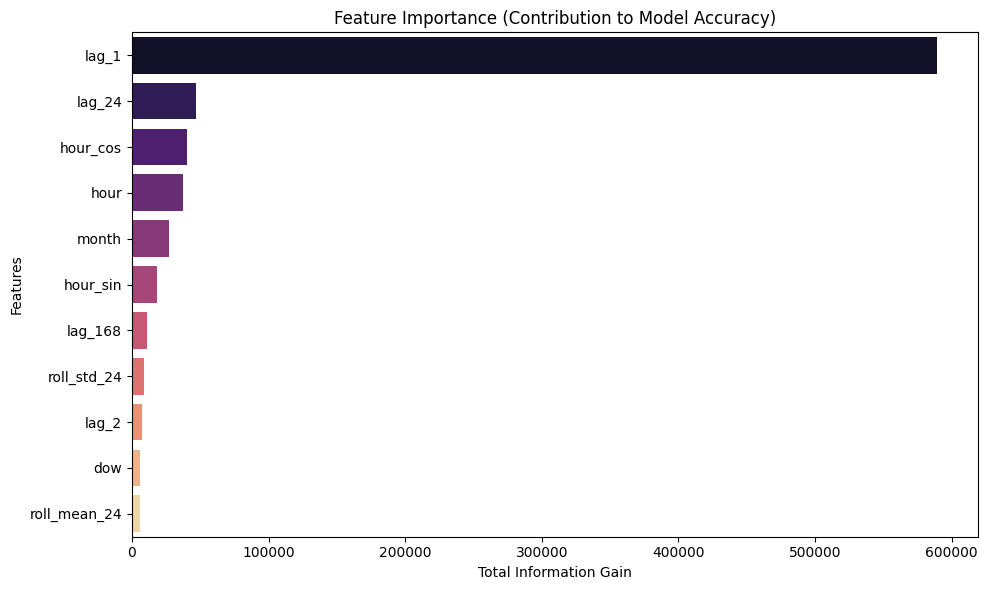

✅ Feature importance chart saved to output!


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Calculating Feature Importances (Gain) from LightGBM...")

# 1. Extract importances from the champion model (LightGBM Median - Quantile 0.5)
champion_model = models[0.5]

# Get the 'gain' importance (how much each feature reduced the error)
importances = champion_model.booster_.feature_importance(importance_type='gain')
feature_names = X_train.columns

# 2. Create a sorted DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance (Gain)': importances
}).sort_values(by='Importance (Gain)', ascending=False)

# Display the extremes in the console
print("\n🔥 MOST Helpful Features:")
display(importance_df.head(5))

print("\n🧊 LEAST Helpful Features:")
display(importance_df.tail(3))

# 3. Plotting the results beautifully
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance (Gain)', y='Feature', data=importance_df, palette='magma')
plt.title("Feature Importance (Contribution to Model Accuracy)")
plt.xlabel("Total Information Gain")
plt.ylabel("Features")
plt.tight_layout()

# 4. Save for your report
SAVE_DIR = '/kaggle/working/'
plt.savefig(os.path.join(SAVE_DIR, 'feature_importance_lgbm.png'), dpi=300)
plt.show()

print("✅ Feature importance chart saved to output!")

Initializing SHAP (Explainable AI)...
Calculating SHAP values (this uses game theory, so it may take a few seconds)...


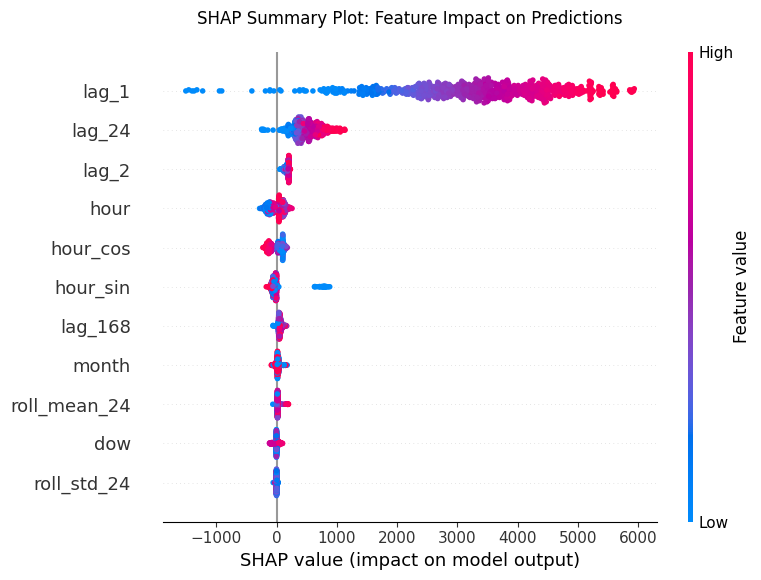


Generating a Local Explanation (Why did the model predict the very last hour?)...


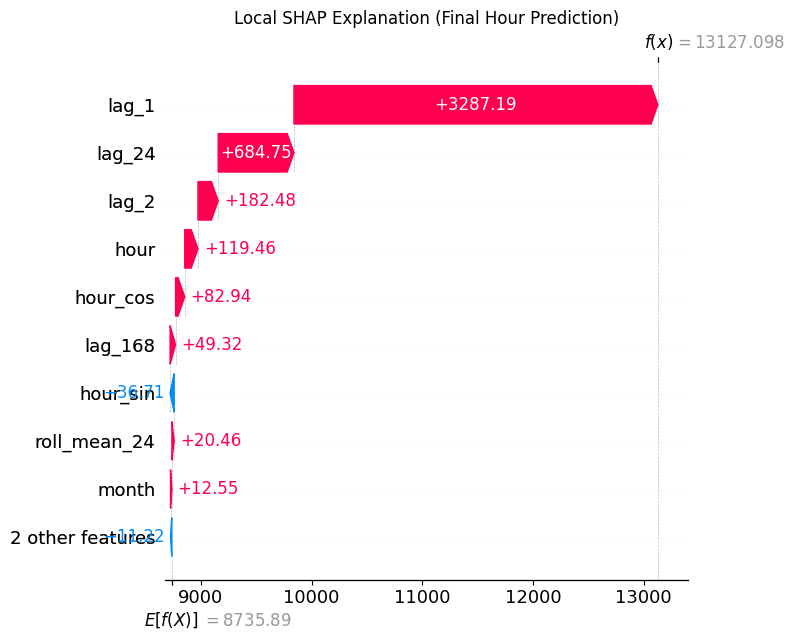

✅ Explainable AI artifacts successfully saved to output!


In [6]:
!pip install shap --quiet

import shap
import matplotlib.pyplot as plt
import os
import pandas as pd

print("Initializing SHAP (Explainable AI)...")

# 1. Initialize the SHAP TreeExplainer with your champion LightGBM model
champion_model = models[0.5]
explainer = shap.TreeExplainer(champion_model)

# 2. Calculate SHAP values
# We use the test set (X_test) so we are explaining how the model behaves on unseen data
print("Calculating SHAP values (this uses game theory, so it may take a few seconds)...")
shap_values = explainer.shap_values(X_test)

# 3. Generate the SHAP Summary Plot
plt.figure(figsize=(10, 6))
# The summary_plot generates its own matplotlib figure, so we set show=False to save it first
shap.summary_plot(shap_values, X_test, show=False)

plt.title("SHAP Summary Plot: Feature Impact on Predictions", pad=20)
plt.tight_layout()

# 4. Save the plot to Kaggle's working directory for your report
SAVE_DIR = '/kaggle/working/'
plt.savefig(os.path.join(SAVE_DIR, 'shap_summary_plot.png'), dpi=300, bbox_inches='tight')
plt.show()

# 5. Generate a Local Explanation (Force Plot) for the very last prediction
print("\nGenerating a Local Explanation (Why did the model predict the very last hour?)...")
# We use a waterfall plot to show exactly how features pushed the base value to the final prediction
plt.figure(figsize=(10, 5))
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value, 
    shap_values[-1], 
    feature_names=X_test.columns, 
    show=False
)
plt.title("Local SHAP Explanation (Final Hour Prediction)")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_local_waterfall.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Explainable AI artifacts successfully saved to output!")

In [7]:
# Change to the working directory just to be safe
%cd /kaggle/working

# Zip everything in the current folder, excluding the zip file itself to prevent a loop
!zip -r all_kaggle_working.zip . -x "all_kaggle_working.zip"


from IPython.display import FileLink

# This creates a direct clickable download hyperlink
FileLink(r'all_kaggle_working.zip')

/kaggle/working
  adding: lstm_training_history.csv (deflated 54%)
  adding: eda_3_dow_avg.png (deflated 27%)
  adding: lgbm_confidence_bands.csv (deflated 58%)
  adding: lgbm_model.pkl (deflated 67%)
  adding: eda_4_distribution.png (deflated 14%)
  adding: scaler_y.pkl (deflated 39%)
  adding: rf_model.pkl (deflated 77%)
  adding: dashboard_data.csv (deflated 59%)
  adding: actual_vs_predicted.png (deflated 5%)
  adding: shap_local_waterfall.png (deflated 16%)
  adding: lstm_loss_curve.png (deflated 18%)
  adding: scaler_X.pkl (deflated 50%)
  adding: eda_2_hourly_avg.png (deflated 25%)
  adding: shap_summary_plot.png (deflated 10%)
  adding: rf_cv_results.csv (deflated 55%)
  adding: lstm_model.pt (deflated 9%)
  adding: feature_importance_lgbm.png (deflated 29%)
  adding: lgbm_quantile_plot.png (deflated 5%)
  adding: evaluation_metrics.csv (deflated 25%)
  adding: prophet_forecast.csv (deflated 75%)
  adding: .virtual_documents/ (stored 0%)
  adding: .virtual_documents/__notebook_

/kaggle/working/all_kaggle_working.zip